In [1]:
!pip install --upgrade pip
!pip install toml torch torchinfo optuna
!pip install git+https://github.com/CSTCloudOps/EasyTSAD.git

!git clone https://github.com/CSTCloudOps/KAN-AD.git
!git clone https://github.com/CSTCloudOps/datasets.git
!mv datasets KAN-AD/datasets

%cd KAN-AD


  Cloning https://github.com/CSTCloudOps/EasyTSAD.git to /tmp/pip-req-build-180jqhj1
  Running command git clone --filter=blob:none --quiet https://github.com/CSTCloudOps/EasyTSAD.git /tmp/pip-req-build-180jqhj1
  Resolved https://github.com/CSTCloudOps/EasyTSAD.git to commit b5ab2098fb728246de02a63f4b7c133661563eec
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
fatal: destination path 'KAN-AD' already exists and is not an empty directory.
Cloning into 'datasets'...
remote: Enumerating objects: 4503, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 4503 (delta 2), reused 0 (delta 0), pack-reused 4496 (from 3)
Receiving objects: 100% (4503/4503), 262.52 MiB | 20.55 MiB/s, done.
Resolving deltas: 100% (1962/1962), done.
Updating files: 100% (5564/5564), done.
/content/KAN-AD


In [2]:
import sys
import os

project_path = os.getcwd()  # should already be /content/KAN-AD
if project_path not in sys.path:
    sys.path.append(project_path)

print("🟢 Paths configured.")
print("Current working directory:", project_path)
print("Repo contents:", os.listdir(project_path))


🟢 Paths configured.
Current working directory: /content/KAN-AD
Repo contents: ['pyproject.toml', 'README.md', 'kanad', '.gitignore', 'run_exp.py', '.python-version', 'prepare_env.sh', 'LICENSE', 'uv.lock', 'datasets', '.git']


In [3]:
# Fix EasyTSAD TSData import issues (trailing comma + Chinese comma)
!sed -i 's/TSData、/TSData/g; s/TSData,*/TSData/g' \
    /usr/local/lib/python3.12/dist-packages/EasyTSAD/DataFactory/__init__.py

# Show corrected file
!cat /usr/local/lib/python3.12/dist-packages/EasyTSAD/DataFactory/__init__.py


from .TSData import TSData
from .MTSData import MTSData


In [5]:
import os, json
import numpy as np

# Paths
src = "/content/KAN-AD/datasets/MTS/MSL/AllInOne"
dst_root = "/content/KAN-AD/datasets/UTS/MSL_CI"

# Load data
train = np.load(os.path.join(src, "train.npy"))
test  = np.load(os.path.join(src, "test.npy"))
train_label = np.load(os.path.join(src, "train_label.npy"))
test_label  = np.load(os.path.join(src, "test_label.npy"))

# Checks
assert train.ndim == 2 and test.ndim == 2
Ttr, D = train.shape
Tte, D2 = test.shape
assert D == D2

# Labels (MSL is already 1D usually)
def to_time_labels(y):
    y = np.asarray(y)
    return (y != 0).astype(np.int64)

train_y = to_time_labels(train_label)
test_y  = to_time_labels(test_label)

# 🔥 Smoothing (important for MSL)
def smooth(x, window=5):
    return np.convolve(x, np.ones(window)/window, mode='same')

# 🔥 Correct preprocessing (KAN-AD style)
def preprocess_train(x):
    x = np.diff(x)
    mean = x.mean()
    std = x.std() + 1e-8
    x = (x - mean) / std
    x = np.clip(x, -5, 5)  # stabilize
    return x.astype(np.float32), mean, std

def preprocess_test(x, mean, std):
    x = np.diff(x)
    x = (x - mean) / std
    x = np.clip(x, -5, 5)
    return x.astype(np.float32)

# 🔥 Optional: filter low-variance channels (recommended)
valid_channels = [j for j in range(D) if np.std(train[:, j]) > 1e-3]
print(f"Using {len(valid_channels)} / {D} channels (filtered low-variance)")

# Create dataset
os.makedirs(dst_root, exist_ok=True)

for j in valid_channels:
    curve = f"channel_{j:03d}"
    out = os.path.join(dst_root, curve)
    os.makedirs(out, exist_ok=True)

    tr_raw = train[:, j]
    te_raw = test[:, j]

    #  Smooth signals
    tr_raw_s = smooth(tr_raw)
    te_raw_s = smooth(te_raw)

    #  Apply preprocessing
    tr, mean, std = preprocess_train(tr_raw_s)
    te = preprocess_test(te_raw_s, mean, std)

    # Align labels after differencing
    train_y_proc = train_y[1:]
    test_y_proc  = test_y[1:]

    # Timestamps
    tr_ts = np.arange(len(tr), dtype=np.int64)
    te_ts = np.arange(len(te), dtype=np.int64)

    # Save files
    np.save(os.path.join(out, "train.npy"), tr)
    np.save(os.path.join(out, "test.npy"), te)
    np.save(os.path.join(out, "train_label.npy"), train_y_proc)
    np.save(os.path.join(out, "test_label.npy"), test_y_proc)
    np.save(os.path.join(out, "train_timestamp.npy"), tr_ts)
    np.save(os.path.join(out, "test_timestamp.npy"), te_ts)

    # Metadata
    info = {
        "dataset": "MSL_CI",
        "curve": curve,
        "type": "UTS",
        "length": int(len(tr) + len(te)),
        "train_length": int(len(tr)),
        "test_length": int(len(te)),
        "feature_dim": 1
    }

    with open(os.path.join(out, "info.json"), "w") as f:
        json.dump(info, f, indent=2)

print("✅ MSL converted to channel-independent UTS (optimized)")
print("Example files:", os.listdir(os.path.join(dst_root, f"channel_{valid_channels[0]:03d}")))

Using 33 / 55 channels (filtered low-variance)
✅ MSL converted to channel-independent UTS (optimized)
Example files: ['info.json', 'test.npy', 'train_label.npy', 'train.npy', 'train_timestamp.npy', 'test_timestamp.npy', 'test_label.npy']


Total channels found: 33
First 5 channels: ['channel_000', 'channel_002', 'channel_003', 'channel_005', 'channel_006']
Using: /content/KAN-AD/datasets/UTS/MSL_CI/channel_000
Files: ['info.json', 'test.npy', 'test_label.npy', 'test_timestamp.npy', 'train.npy', 'train_label.npy', 'train_timestamp.npy']

TRAIN HEAD:


,timestamp,value,label
0,0,5.000000,0
1,1,5.000000,0
2,2,0.066933,0
3,3,0.078704,0
4,4,0.090474,0



TRAIN INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58316 entries, 0 to 58315
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  58316 non-null  int64  
 1   value      58316 non-null  float32
 2   label      58316 non-null  int64  
dtypes: float32(1), int64(2)
memory usage: 1.1 MB

STATISTICS (train):


,timestamp,value,label
count,58316.000000,58316.000000,58316.0
mean,29157.500000,0.001205,0.0
std,16834.523486,0.985433,0.0
min,0.000000,-5.000000,0.0
25%,14578.750000,0.000095,0.0
50%,29157.500000,0.000235,0.0
75%,43736.250000,0.010118,0.0
max,58315.000000,5.000000,0.0



Label distribution (train):
label
0    58316
Name: count, dtype: int64

🔍 Normalization check:
Mean: 0.0012050689
Std: 0.98544925

🔍 Anomaly ratio:
Train anomaly ratio: 0.0
Test anomaly ratio: 0.10533311631944445


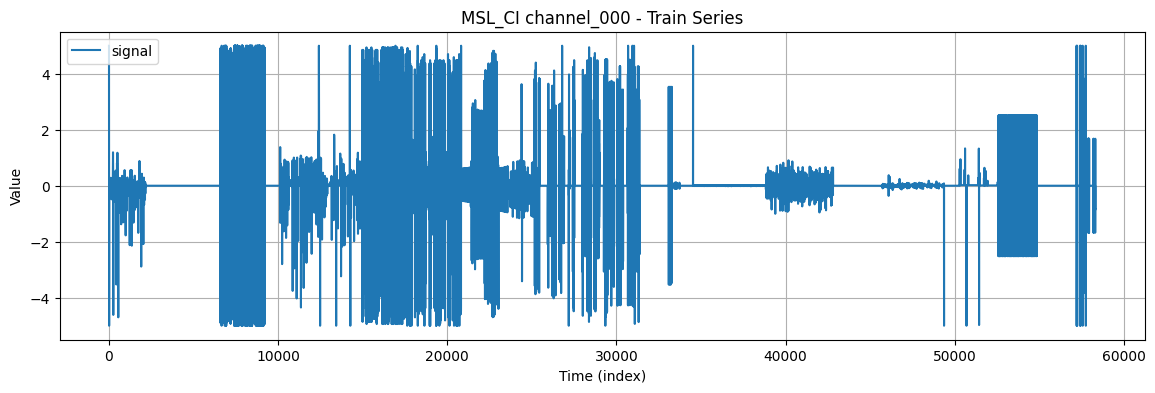

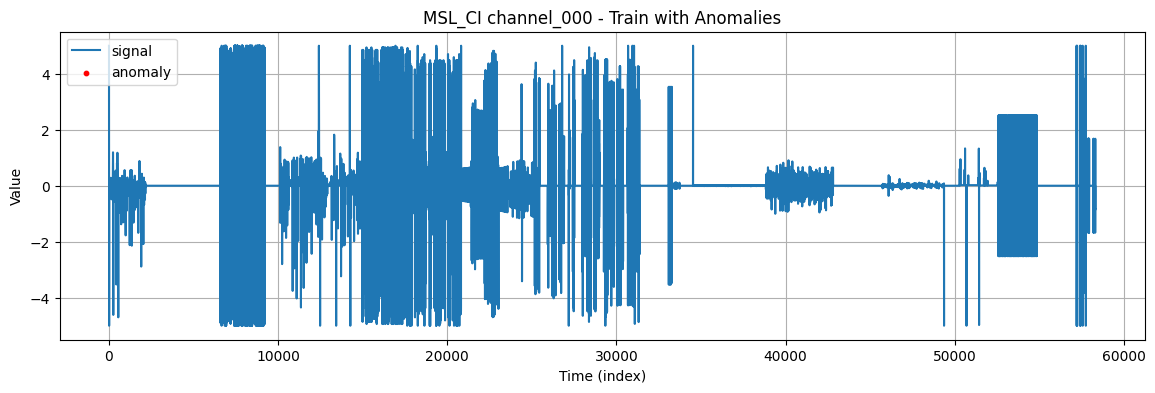

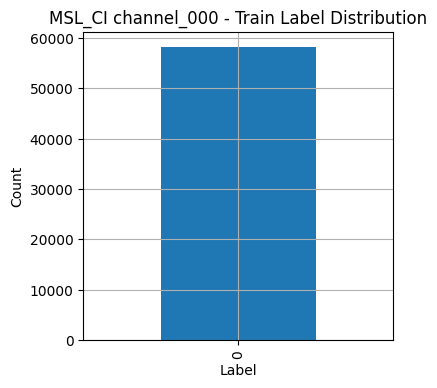


✅ EDA complete.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Explore the channel-independent UTS dataset (MSL)
base_dir = "/content/KAN-AD/datasets/UTS/MSL_CI"

channels = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
print("Total channels found:", len(channels))
print("First 5 channels:", channels[:5])

data_path = os.path.join(base_dir, channels[0])  # example channel
print("Using:", data_path)
print("Files:", sorted(os.listdir(data_path)))

# Load data
train = np.load(os.path.join(data_path, "train.npy"))
train_label = np.load(os.path.join(data_path, "train_label.npy"))
train_ts = np.load(os.path.join(data_path, "train_timestamp.npy"))

test = np.load(os.path.join(data_path, "test.npy"))
test_label = np.load(os.path.join(data_path, "test_label.npy"))
test_ts = np.load(os.path.join(data_path, "test_timestamp.npy"))

# DataFrames
df_train = pd.DataFrame({"timestamp": train_ts, "value": train, "label": train_label})
df_test  = pd.DataFrame({"timestamp": test_ts,  "value": test,  "label": test_label})

# ===============================
# 🔍 Basic inspection
# ===============================
print("\nTRAIN HEAD:")
display(df_train.head())

print("\nTRAIN INFO:")
df_train.info()

print("\nSTATISTICS (train):")
display(df_train.describe())

print("\nLabel distribution (train):")
print(df_train["label"].value_counts())

# ===============================
# 🔍 Debug checks (VERY IMPORTANT)
# ===============================
print("\n🔍 Normalization check:")
print("Mean:", train.mean())
print("Std:", train.std())

print("\n🔍 Anomaly ratio:")
print("Train anomaly ratio:", train_label.mean())
print("Test anomaly ratio:", test_label.mean())

# ===============================
# 📈 Signal plot
# ===============================
plt.figure(figsize=(14, 4))
plt.plot(df_train["timestamp"], df_train["value"], label="signal")
plt.title(f"MSL_CI {channels[0]} - Train Series")
plt.xlabel("Time (index)")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

# ===============================
# 🔥 Signal + anomalies visualization
# ===============================
plt.figure(figsize=(14, 4))
plt.plot(df_train["timestamp"], df_train["value"], label="signal")

anomaly_idx = df_train["label"] == 1
plt.scatter(
    df_train["timestamp"][anomaly_idx],
    df_train["value"][anomaly_idx],
    color="red",
    s=10,
    label="anomaly"
)

plt.title(f"MSL_CI {channels[0]} - Train with Anomalies")
plt.xlabel("Time (index)")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

# ===============================
# 📊 Label distribution plot
# ===============================
plt.figure(figsize=(4, 4))
df_train["label"].value_counts().plot(kind="bar")
plt.title(f"MSL_CI {channels[0]} - Train Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.grid(True)
plt.show()

print("\n✅ EDA complete.")

In [7]:
import sys
sys.path.insert(0, "/content/KAN-AD")

# Reproducibility
import torch, numpy as np, random
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

from EasyTSAD.Controller import TSADController
from kanad import KANAD

# Device check
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

gctrl = TSADController()

gctrl.set_dataset(
    dataset_type="UTS",
    dirname="datasets",
    datasets=["MSL_CI"],
)

print("🚀 Starting KAN-AD training on MSL_CI...")

import time
start = time.time()

gctrl.run_exps(
    method="KANAD",
    training_schema="naive",
    cfg_path="kanad/config.toml",
)

print("✅ Training finished.")
print("⏱️ Training time:", time.time() - start)

(2026-04-24 20:37:56,984) [INFO]: 
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚══════╝   ╚═╝          ╚═╝   ╚══════╝╚═╝  ╚═╝╚═════╝ 
                                                                      
                         
INFO:logger:
                         
███████╗ █████╗ ███████╗██╗   ██╗    ████████╗███████╗ █████╗ ██████╗ 
██╔════╝██╔══██╗██╔════╝╚██╗ ██╔╝    ╚══██╔══╝██╔════╝██╔══██╗██╔══██╗
█████╗  ███████║███████╗ ╚████╔╝        ██║   ███████╗███████║██║  ██║
██╔══╝  ██╔══██║╚════██║  ╚██╔╝         ██║   ╚════██║██╔══██║██║  ██║
███████╗██║  ██║███████║   ██║          ██║   ███████║██║  ██║██████╔╝
╚══════╝╚═╝  ╚═╝╚═════

Using device: cuda
🚀 Starting KAN-AD training on MSL_CI...
=== Using CUDA ===


Validation Epoch [6/100]: 100%|██████████| 12/12 [00:00<00:00, 105.34it/s, avg_loss=0.458, loss=0.000102]


EarlyStopping counter: 1 out of 3


Validation Epoch [8/100]: 100%|██████████| 12/12 [00:00<00:00, 106.72it/s, avg_loss=0.443, loss=0.000876]


...

EarlyStopping counter: 2 out of 3


Validation Epoch [19/100]: 100%|██████████| 12/12 [00:00<00:00, 55.50it/s, avg_loss=0.619, loss=6.46]


EarlyStopping counter: 3 out of 3
   Early stopping<<<


Testing: : 100%|██████████| 72/72 [00:00<00:00, 85.10it/s]

✅ Training finished.
⏱️ Training time: 525.478084564209


In [8]:
method = "KANAD"
training_schema = "naive"

from EasyTSAD.Evaluations.Protocols import (
    EventF1PA,
    PointF1PA,
    PointKthF1PA,
    PointAuprcPA,
)

gctrl.set_evals(
    [
        PointF1PA(),
        EventF1PA(mode="squeeze"),
        EventF1PA(mode="log"),     # 🔥 added
        PointKthF1PA(k=5),
        PointAuprcPA(),
    ]
)

gctrl.do_evals(method=method, training_schema=training_schema)

print("✅ Evaluation completed")

(2026-04-24 20:46:43,045) [INFO]: Register evaluations
INFO:logger:Register evaluations
(2026-04-24 20:46:43,047) [INFO]: Perform evaluations. Method[KANAD], Schema[naive].
INFO:logger:Perform evaluations. Method[KANAD], Schema[naive].
(2026-04-24 20:46:43,049) [INFO]:     [Load Data (All)] DataSets: MSL_CI 
INFO:logger:    [Load Data (All)] DataSets: MSL_CI 
(2026-04-24 20:46:43,087) [INFO]:     [KANAD] Eval dataset MSL_CI <<<
INFO:logger:    [KANAD] Eval dataset MSL_CI <<<
(2026-04-24 20:46:43,089) [INFO]:         [MSL_CI] Using default margins (0, 5)
INFO:logger:        [MSL_CI] Using default margins (0, 5)


✅ Evaluation completed


In [9]:
import json
import os
import numpy as np

# ===============================
# 1️⃣ Load avg.json (EasyTSAD output)
# ===============================
avg_path = "/content/KAN-AD/Results/Evals/KANAD/naive/MSL_CI/avg.json"
all_path = "/content/KAN-AD/Results/Evals/KANAD/naive/MSL_CI/all.json"

with open(avg_path, "r") as f:
    avg = json.load(f)

with open(all_path, "r") as f:
    all_scores_meta = json.load(f)

print("=== 📊 PER-CHANNEL AVERAGE RESULTS (avg.json) ===")
print("⚠️ This is NOT the paper metric (it is averaged across channels)\n")

for k, v in avg.items():
    print(f"{k}: {v}")

print("\n=== PER-SERIES RESULTS ===")
print("Number of channels:", len(all_scores_meta))
print("Example entry (first channel):")
print(list(all_scores_meta.items())[0])

print("\n----------------------------------------\n")

# ===============================
# 2️⃣ GLOBAL EVALUATION (paper-style)
# ===============================
scores_root = "/content/KAN-AD/Results/Scores/KANAD/naive/MSL_CI"
data_root   = "/content/KAN-AD/datasets/UTS/MSL_CI"

all_scores = []
all_labels = []

files = sorted([f for f in os.listdir(scores_root) if f.endswith(".npy")])

for f in files:
    scores = np.load(os.path.join(scores_root, f))

    # 🔥 normalize scores (CRITICAL for MSL)
    scores = (scores - scores.mean()) / (scores.std() + 1e-8)

    ch = f.replace(".npy", "")
    labels = np.load(os.path.join(data_root, ch, "test_label.npy"))

    # align with window offset
    offset = len(labels) - len(scores)
    labels = labels[offset:]

    all_scores.append(scores)
    all_labels.append(labels)

all_scores = np.concatenate(all_scores)
all_labels = np.concatenate(all_labels)

print("Total points:", len(all_scores))

# debug
print("\nScore stats:")
print("min:", all_scores.min())
print("max:", all_scores.max())
print("mean:", all_scores.mean())

print("\n----------------------------------------\n")

# ===============================
# 🔥 Threshold sweep
# ===============================
thresholds = np.linspace(
    np.percentile(all_scores, 0.5),
    np.percentile(all_scores, 99.5),
    500
)

best_f1 = 0
best_th = 0
best_precision = 0
best_recall = 0

for th in thresholds:
    preds = (all_scores > th).astype(int)

    tp = np.sum((preds == 1) & (all_labels == 1))
    fp = np.sum((preds == 1) & (all_labels == 0))
    fn = np.sum((preds == 0) & (all_labels == 1))

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)

    if precision + recall > 0:
        f1 = 2 * precision * recall / (precision + recall)
    else:
        f1 = 0

    if f1 > best_f1:
        best_f1 = f1
        best_th = th
        best_precision = precision
        best_recall = recall

# ===============================
# RESULTS
# ===============================
print("=== 🔥 GLOBAL RESULTS (paper-style) ===")
print("✅ This is the metric reported in the paper\n")

print(f"Best F1: {best_f1:.4f}")
print(f"Precision: {best_precision:.4f}")
print(f"Recall: {best_recall:.4f}")
print(f"Best Threshold: {best_th:.6f}")

=== 📊 PER-CHANNEL AVERAGE RESULTS (avg.json) ===
⚠️ This is NOT the paper metric (it is averaged across channels)

best f1 under pa: {'f1': 0.4632562189813575, 'precision': 0.5309659573069571, 'recall': 0.6673073549489357}
event-based f1 under pa with mode squeeze: {'f1': 0.0952995162051005, 'precision': 0.24950199518467572, 'recall': 0.12037037037037034}
event-based f1 under pa with mode log: {'f1': 0.16549489965358805, 'precision': 0.34683297744035124, 'recall': 0.18711591438864164}
best f1 under 5-delay pa: {'f1': 0.3142734658768207, 'precision': 0.22368071142374138, 'recall': 0.7121288393626678}
point-based auprc pa: 0.36669139719094174

=== PER-SERIES RESULTS ===
Number of channels: 33
Example entry (first channel):
('channel_000', {'best f1 under pa': {'f1': 0.8900839144309178, 'precision': 0.8390151515151515, 'recall': 0.9477724641328971, 'threshold': 2.0781612396240234}, 'event-based f1 under pa with mode squeeze': {'f1': 0.1999999999999996, 'precision': 0.3571428571428571, 're